In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
!pip install  opencv-python-headless pandas numpy scikit-learn xgboost onnxmltools onnx onnxruntime matplotlib seaborn
!pip install mediapipe==0.10.13

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 304.0/304.0 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 28.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 25.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 4.25.8 which is incompatible.
opentelemetry-proto 1.38.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.25.8 which

In [ ]:
import pandas as pd

# Load the training labels
train_labels = pd.read_csv('/content/drive/MyDrive/DAiSEE/Labels/TrainLabels.csv')

# See first few rows
print("Shape:", train_labels.shape)
print("\nFirst 5 rows:")
train_labels.head()

Shape: (5358, 5)

First 5 rows:


,ClipID,Boredom,Engagement,Confusion,Frustration
0,1100011002.avi,0,2,0,0
1,1100011003.avi,0,2,0,0
2,1100011004.avi,0,3,0,0
3,1100011005.avi,0,3,0,0
4,1100011006.avi,0,3,0,0


In [ ]:
# Check exact column names
print(train_labels.columns.tolist())

# Fix any hidden spaces in column names
train_labels.columns = train_labels.columns.str.strip()

# Verify
print("Fixed columns:", train_labels.columns.tolist())

['ClipID', 'Boredom', 'Engagement', 'Confusion', 'Frustration ']
Fixed columns: ['ClipID', 'Boredom', 'Engagement', 'Confusion', 'Frustration']


In [ ]:
def get_attention_label(row):
    if row['Engagement'] >= 2 and row['Boredom'] <= 1:
        return 'Attentive'
    elif row['Boredom'] >= 2:
        return 'Bored'
    elif row['Confusion'] >= 2:
        return 'Confused'
    else:
        return 'Frustrated'

train_labels['attention'] = train_labels.apply(get_attention_label, axis=1)

print("Attention label distribution:")
print(train_labels['attention'].value_counts())

Attention label distribution:
attention
Attentive     4057
Bored         1229
Frustrated      56
Confused        16
Name: count, dtype: int64


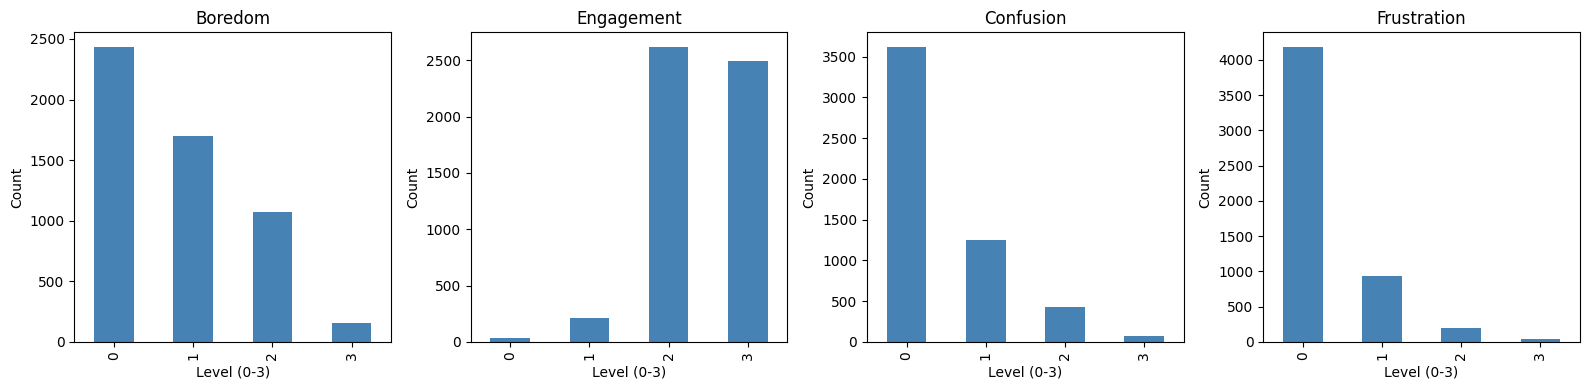

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
labels = ['Boredom', 'Engagement', 'Confusion', 'Frustration']

for i, label in enumerate(labels):
    train_labels[label].value_counts().sort_index().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(label)
    axes[i].set_xlabel('Level (0-3)')
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
def get_attention_label(row):
    if row['Engagement'] >= 2 and row['Boredom'] <= 1:
        return 'Attentive'
    elif row['Boredom'] >= 2:
        return 'Bored'
    elif row['Confusion'] >= 2:
        return 'Confused'
    else:
        return 'Frustrated'

train_labels['attention'] = train_labels.apply(get_attention_label, axis=1)

# Check distribution
print("Attention label distribution:")
print(train_labels['attention'].value_counts())
print("\nPercentage:")
print(train_labels['attention'].value_counts(normalize=True).round(3) * 100)

Attention label distribution:
attention
Attentive     4057
Bored         1229
Frustrated      56
Confused        16
Name: count, dtype: int64

Percentage:
attention
Attentive     75.7
Bored         22.9
Frustrated     1.0
Confused       0.3
Name: proportion, dtype: float64


In [ ]:
import os

# Check what's inside the Train folder
train_path = '/content/drive/MyDrive/DAiSEE/DataSet/Train'

# Count videos and show sample structure
all_videos = []
for root, dirs, files in os.walk(train_path):
    for file in files:
        if file.endswith('.avi'):
            all_videos.append({
                'ClipID': file,
                'full_path': os.path.join(root, file)
            })

print(f"Total videos found: {len(all_videos)}")
print("\nSample paths:")
for v in all_videos[:5]:
    print(v['full_path'])

Total videos found: 4975

Sample paths:
/content/drive/MyDrive/DAiSEE/DataSet/Train/459999/4599990276/4599990276.avi
/content/drive/MyDrive/DAiSEE/DataSet/Train/459999/4599990283/4599990283.avi
/content/drive/MyDrive/DAiSEE/DataSet/Train/459999/459999028/459999028.avi
/content/drive/MyDrive/DAiSEE/DataSet/Train/459999/4599990275/4599990275.avi
/content/drive/MyDrive/DAiSEE/DataSet/Train/459999/4599990273/4599990273.avi


In [ ]:
import pandas as pd

# Convert to dataframe
video_df = pd.DataFrame(all_videos)

# Merge with labels
merged = pd.merge(video_df, train_labels[['ClipID', 'attention']], on='ClipID', how='inner')

print(f"Total matched videos: {len(merged)}")
print("\nSample:")
print(merged.head())
print("\nLabel distribution in matched data:")
print(merged['attention'].value_counts())

Total matched videos: 4851

Sample:
           ClipID                                          full_path  \
0   459999025.avi  /content/drive/MyDrive/DAiSEE/DataSet/Train/45...   
1  4599990248.avi  /content/drive/MyDrive/DAiSEE/DataSet/Train/45...   
2  4599990247.avi  /content/drive/MyDrive/DAiSEE/DataSet/Train/45...   
3  4599990249.avi  /content/drive/MyDrive/DAiSEE/DataSet/Train/45...   
4  4599990244.avi  /content/drive/MyDrive/DAiSEE/DataSet/Train/45...   

   attention  
0  Attentive  
1  Attentive  
2  Attentive  
3  Attentive  
4  Attentive  

Label distribution in matched data:
attention
Attentive     3596
Bored         1190
Frustrated      50
Confused        15
Name: count, dtype: int64


In [ ]:
import cv2
import mediapipe as mp
import numpy as np

# ✅ This works with mediapipe 0.10.13+
face_mesh = mp.solutions.face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

LEFT_EYE  = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33,  160, 158, 133, 153, 144]

def euclidean(p1, p2):
    return np.sqrt((p1.x - p2.x)**2 + (p1.y - p2.y)**2)

def calculate_ear(landmarks, eye_indices):
    p = [landmarks[i] for i in eye_indices]
    vertical1  = euclidean(p[1], p[5])
    vertical2  = euclidean(p[2], p[4])
    horizontal = euclidean(p[0], p[3])
    return (vertical1 + vertical2) / (2.0 * horizontal)

def extract_features_from_video(video_path):
    cap = cv2.VideoCapture(video_path)
    ear_values = []

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb)

        if results.multi_face_landmarks:
            lm        = results.multi_face_landmarks[0].landmark
            left_ear  = calculate_ear(lm, LEFT_EYE)
            right_ear = calculate_ear(lm, RIGHT_EYE)
            ear_values.append((left_ear + right_ear) / 2.0)

    cap.release()

    if len(ear_values) == 0:
        return None

    ear_array = np.array(ear_values)
    return {
        'avg_ear'    : round(float(np.mean(ear_array)), 4),
        'std_ear'    : round(float(np.std(ear_array)), 4),
        'min_ear'    : round(float(np.min(ear_array)), 4),
        'perclos'    : round(float(np.mean(ear_array < 0.2)), 4),
        'blink_count': int(np.sum(np.diff((ear_array < 0.2).astype(int)) == 1))
    }

# ✅ Test on 5 videos first
print("Testing on 5 videos...\n")
for _, row in merged.head(5).iterrows():
    features = extract_features_from_video(row['full_path'])
    print(f"ClipID : {row['ClipID']}")
    print(f"Label  : {row['attention']}")
    print(f"Features: {features}")
    print("-" * 50)

Testing on 5 videos...



/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


ClipID : 459999025.avi
Label  : Attentive
Features: {'avg_ear': 0.3678, 'std_ear': 0.0183, 'min_ear': 0.2724, 'perclos': 0.0, 'blink_count': 0}
--------------------------------------------------
ClipID : 4599990248.avi
Label  : Attentive
Features: {'avg_ear': 0.385, 'std_ear': 0.0175, 'min_ear': 0.3051, 'perclos': 0.0, 'blink_count': 0}
--------------------------------------------------
ClipID : 4599990247.avi
Label  : Attentive
Features: {'avg_ear': 0.4016, 'std_ear': 0.0119, 'min_ear': 0.3721, 'perclos': 0.0, 'blink_count': 0}
--------------------------------------------------
ClipID : 4599990249.avi
Label  : Attentive
Features: {'avg_ear': 0.3787, 'std_ear': 0.0167, 'min_ear': 0.2801, 'perclos': 0.0, 'blink_count': 0}
--------------------------------------------------
ClipID : 4599990244.avi
Label  : Attentive
Features: {'avg_ear': 0.3945, 'std_ear': 0.0165, 'min_ear': 0.3063, 'perclos': 0.0, 'blink_count': 0}
--------------------------------------------------


In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

In [ ]:


output_csv = '/content/drive/MyDrive/DAiSEE/train_features.csv'

# ✅ RESUME LOGIC - Load already processed videos if file exists
if os.path.exists(output_csv):
    already_done = pd.read_csv(output_csv)
    done_ids = set(already_done['ClipID'].tolist())
    results_list = already_done.to_dict('records')
    print(f"✅ Resuming! Already processed: {len(done_ids)} videos")
else:
    already_done = pd.DataFrame()
    done_ids = set()
    results_list = []
    print("🆕 Starting fresh extraction...")

# Filter out already processed videos
remaining = merged[~merged['ClipID'].isin(done_ids)]
print(f"📋 Remaining videos to process: {len(remaining)}")
print("This may take a while. Keep the tab open!\n")

failed_videos = []

for idx, row in tqdm(remaining.iterrows(), total=len(remaining)):
    try:
        features = extract_features_from_video(row['full_path'])

        if features is not None:
            features['ClipID']    = row['ClipID']
            features['attention'] = row['attention']
            results_list.append(features)
        else:
            failed_videos.append(row['ClipID'])

    except Exception as e:
        failed_videos.append(row['ClipID'])
        continue

    # ✅ Save every 50 videos to Drive
    if len(results_list) % 50 == 0 and len(results_list) > 0:
        pd.DataFrame(results_list).to_csv(output_csv, index=False)
        print(f"💾 Checkpoint saved — {len(results_list)} videos done so far...")

# Final save
final_df = pd.DataFrame(results_list)
final_df.to_csv(output_csv, index=False)

print(f"\n✅ DONE!")
print(f"Successfully extracted : {len(results_list)} videos")
print(f"Failed/skipped         : {len(failed_videos)} videos")
print(f"Saved to               : {output_csv}")
print("\nLabel distribution:")
print(final_df['attention'].value_counts())

✅ Resuming! Already processed: 4851 videos
📋 Remaining videos to process: 0
This may take a while. Keep the tab open!



0it [00:00, ?it/s]


✅ DONE!
Successfully extracted : 4851 videos
Failed/skipped         : 0 videos
Saved to               : /content/drive/MyDrive/DAiSEE/train_features.csv

Label distribution:
attention
Attentive     3596
Bored         1190
Frustrated      50
Confused        15
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load extracted features
df = pd.read_csv('/content/drive/MyDrive/DAiSEE/train_features.csv')

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nAny missing values?")
print(df.isnull().sum())

Dataset shape: (4851, 7)

First 5 rows:
   avg_ear  std_ear  min_ear  perclos  blink_count          ClipID  attention
0   0.3678   0.0182   0.2722      0.0            0   459999025.avi  Attentive
1   0.3850   0.0175   0.3067      0.0            0  4599990248.avi  Attentive
2   0.4016   0.0118   0.3732      0.0            0  4599990247.avi  Attentive
3   0.3787   0.0166   0.2798      0.0            0  4599990249.avi  Attentive
4   0.3945   0.0166   0.3070      0.0            0  4599990244.avi  Attentive

Any missing values?
avg_ear        0
std_ear        0
min_ear        0
perclos        0
blink_count    0
ClipID         0
attention      0
dtype: int64


In [ ]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

# Features and labels
X = df[['avg_ear', 'std_ear', 'min_ear', 'perclos', 'blink_count']]
y = df['attention']

# Encode labels to numbers
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

print(f"\nBefore SMOTE: {pd.Series(y_encoded).value_counts().to_dict()}")

# Balance the dataset
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y_encoded)

print(f"After SMOTE : {pd.Series(y_balanced).value_counts().to_dict()}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Label mapping:
  0 → Attentive
  1 → Bored
  2 → Confused
  3 → Frustrated

Before SMOTE: {0: 3596, 1: 1190, 3: 50, 2: 15}
After SMOTE : {0: 3596, 1: 3596, 3: 3596, 2: 3596}

Training samples : 11507
Testing samples  : 2877


In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# Train model
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    eval_metric='mlogloss'
)

print("Training XGBoost model...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Training XGBoost model...
[0]	validation_0-mlogloss:1.33430
[50]	validation_0-mlogloss:0.84756
[100]	validation_0-mlogloss:0.77037
[150]	validation_0-mlogloss:0.71775
[199]	validation_0-mlogloss:0.67930

✅ Accuracy: 71.88%

Detailed Report:
              precision    recall  f1-score   support

   Attentive       0.63      0.50      0.56       719
       Bored       0.64      0.57      0.60       719
    Confused       0.83      0.92      0.87       720
  Frustrated       0.73      0.89      0.80       719

    accuracy                           0.72      2877
   macro avg       0.71      0.72      0.71      2877
weighted avg       0.71      0.72      0.71      2877



In [ ]:
import pickle

model_path   = '/content/drive/MyDrive/DAiSEE/xgboost_attention_model.pkl'
encoder_path = '/content/drive/MyDrive/DAiSEE/label_encoder.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

with open(encoder_path, 'wb') as f:
    pickle.dump(le, f)

print("✅ Model saved to Drive!")


✅ Model saved to Drive!


In [ ]:
def extract_features_from_video(video_path):
    cap = cv2.VideoCapture(video_path)
    ear_values = []
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1
        rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb)

        if results.multi_face_landmarks:
            lm        = results.multi_face_landmarks[0].landmark
            left_ear  = calculate_ear(lm, LEFT_EYE)
            right_ear = calculate_ear(lm, RIGHT_EYE)
            ear_values.append((left_ear + right_ear) / 2.0)

    cap.release()

    if len(ear_values) == 0:
        return None

    ear_array = np.array(ear_values)
    blink_signal = (ear_array < 0.2).astype(int)
    blinks = np.diff(blink_signal)

    return {
        # EAR features
        'avg_ear'        : round(float(np.mean(ear_array)), 4),
        'std_ear'        : round(float(np.std(ear_array)), 4),
        'min_ear'        : round(float(np.min(ear_array)), 4),
        'max_ear'        : round(float(np.max(ear_array)), 4),
        'median_ear'     : round(float(np.median(ear_array)), 4),

        # Blink features
        'perclos'        : round(float(np.mean(ear_array < 0.2)), 4),
        'blink_count'    : int(np.sum(blinks == 1)),
        'blink_rate'     : round(float(np.sum(blinks == 1)) / max(frame_count / 30, 1), 4),

        # Variability features
        'ear_range'      : round(float(np.max(ear_array) - np.min(ear_array)), 4),
        'ear_q25'        : round(float(np.percentile(ear_array, 25)), 4),
        'ear_q75'        : round(float(np.percentile(ear_array, 75)), 4),
    }


In [ ]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

output_csv2 = '/content/drive/MyDrive/DAiSEE/train_features_v2.csv'

# ✅ RESUME LOGIC
if os.path.exists(output_csv2):
    already_done = pd.read_csv(output_csv2)
    done_ids     = set(already_done['ClipID'].tolist())
    results_list2 = already_done.to_dict('records')
    print(f"✅ Resuming! Already processed: {len(done_ids)} videos")
else:
    done_ids      = set()
    results_list2 = []
    print("🆕 Starting fresh extraction...")

# Filter remaining
remaining2 = merged[~merged['ClipID'].isin(done_ids)]
print(f"📋 Remaining videos to process: {len(remaining2)}\n")

failed_videos2 = []

for idx, row in tqdm(remaining2.iterrows(), total=len(remaining2)):
    try:
        features = extract_features_from_video(row['full_path'])
        if features is not None:
            features['ClipID']    = row['ClipID']
            features['attention'] = row['attention']
            results_list2.append(features)
        else:
            failed_videos2.append(row['ClipID'])
    except Exception as e:
        failed_videos2.append(row['ClipID'])
        continue

    # ✅ Save every 50 videos
    if len(results_list2) % 50 == 0 and len(results_list2) > 0:
        pd.DataFrame(results_list2).to_csv(output_csv2, index=False)
        print(f"💾 Checkpoint saved — {len(results_list2)} videos done...")

# Final save
pd.DataFrame(results_list2).to_csv(output_csv2, index=False)
print(f"\n✅ Done! Extracted {len(results_list2)} videos with 11 features")
print(f"Failed: {len(failed_videos2)} videos")

✅ Resuming! Already processed: 4851 videos
📋 Remaining videos to process: 0



0it [00:00, ?it/s]


✅ Done! Extracted 4851 videos with 11 features
Failed: 0 videos


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score

# Load new features
df2 = pd.read_csv('/content/drive/MyDrive/DAiSEE/train_features_v2.csv')

print("Dataset shape:", df2.shape)
print("Columns:", df2.columns.tolist())

# Features and labels
feature_cols = ['avg_ear', 'std_ear', 'min_ear', 'max_ear', 'median_ear',
                'perclos', 'blink_count', 'blink_rate', 'ear_range', 'ear_q25', 'ear_q75']

X = df2[feature_cols]
y = df2['attention']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nLabel mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# Balance with SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y_encoded)
print(f"\nAfter SMOTE: {pd.Series(y_balanced).value_counts().to_dict()}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

# Train XGBoost
print("\nTraining XGBoost model...")
model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    eval_metric='mlogloss',
    subsample=0.8,
    colsample_bytree=0.8
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50
)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Dataset shape: (4851, 13)
Columns: ['avg_ear', 'std_ear', 'min_ear', 'max_ear', 'median_ear', 'perclos', 'blink_count', 'blink_rate', 'ear_range', 'ear_q25', 'ear_q75', 'ClipID', 'attention']

Label mapping:
  0 → Attentive
  1 → Bored
  2 → Confused
  3 → Frustrated

After SMOTE: {0: 3596, 1: 3596, 3: 3596, 2: 3596}

Training XGBoost model...
[0]	validation_0-mlogloss:1.35255
[50]	validation_0-mlogloss:0.72486
[100]	validation_0-mlogloss:0.59750
[150]	validation_0-mlogloss:0.54112
[200]	validation_0-mlogloss:0.50091
[250]	validation_0-mlogloss:0.46830
[299]	validation_0-mlogloss:0.44500

✅ Accuracy: 82.45%

Detailed Report:
              precision    recall  f1-score   support

   Attentive       0.74      0.64      0.68       719
       Bored       0.72      0.72      0.72       719
    Confused       0.94      0.98      0.96       720
  Frustrated       0.88      0.95      0.91       719

    accuracy                           0.82      2877
   macro avg       0.82      0.82      0.

In [ ]:
import pickle

model_path   = '/content/drive/MyDrive/DAiSEE/xgboost_v2.pkl'
encoder_path = '/content/drive/MyDrive/DAiSEE/label_encoder_v2.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

with open(encoder_path, 'wb') as f:
    pickle.dump(le, f)

print("✅ Model v2 saved to Drive!")

✅ Model v2 saved to Drive!


In [ ]:
import cv2
import mediapipe as mp
import numpy as np

face_mesh = mp.solutions.face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

LEFT_EYE  = [362, 385, 387, 263, 373, 380]
RIGHT_EYE = [33,  160, 158, 133, 153, 144]

# 3D model points for head pose
MODEL_POINTS = np.array([
    (0.0,    0.0,    0.0),      # Nose tip
    (0.0,   -330.0, -65.0),     # Chin
    (-225.0, 170.0, -135.0),    # Left eye corner
    (225.0,  170.0, -135.0),    # Right eye corner
    (-150.0, -150.0, -125.0),   # Left mouth corner
    (150.0,  -150.0, -125.0)    # Right mouth corner
], dtype=np.float64)

# Landmark indices for pose
POSE_LANDMARKS = [1, 152, 263, 33, 287, 57]

def euclidean(p1, p2):
    return np.sqrt((p1.x - p2.x)**2 + (p1.y - p2.y)**2)

def calculate_ear(landmarks, eye_indices):
    p = [landmarks[i] for i in eye_indices]
    vertical1  = euclidean(p[1], p[5])
    vertical2  = euclidean(p[2], p[4])
    horizontal = euclidean(p[0], p[3])
    return (vertical1 + vertical2) / (2.0 * horizontal)

def get_head_pose(landmarks, frame_shape):
    h, w = frame_shape[:2]
    image_points = np.array([
        (landmarks[1].x * w,   landmarks[1].y * h),
        (landmarks[152].x * w, landmarks[152].y * h),
        (landmarks[263].x * w, landmarks[263].y * h),
        (landmarks[33].x * w,  landmarks[33].y * h),
        (landmarks[287].x * w, landmarks[287].y * h),
        (landmarks[57].x * w,  landmarks[57].y * h)
    ], dtype=np.float64)

    focal_length = w
    center = (w / 2, h / 2)
    camera_matrix = np.array([
        [focal_length, 0, center[0]],
        [0, focal_length, center[1]],
        [0, 0, 1]
    ], dtype=np.float64)

    dist_coeffs = np.zeros((4, 1))
    success, rvec, tvec = cv2.solvePnP(
        MODEL_POINTS, image_points, camera_matrix, dist_coeffs
    )

    if not success:
        return None, None

    rmat, _ = cv2.Rodrigues(rvec)
    angles, _, _, _, _, _ = cv2.RQDecomp3x3(rmat)
    pitch = angles[0]  # up/down
    yaw   = angles[1]  # left/right
    return pitch, yaw

def extract_features_from_video(video_path):
    cap = cv2.VideoCapture(video_path)
    ear_values   = []
    pitch_values = []
    yaw_values   = []
    frame_count  = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1
        rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb)

        if results.multi_face_landmarks:
            lm = results.multi_face_landmarks[0].landmark

            # EAR
            left_ear  = calculate_ear(lm, LEFT_EYE)
            right_ear = calculate_ear(lm, RIGHT_EYE)
            ear_values.append((left_ear + right_ear) / 2.0)

            # Head Pose
            pitch, yaw = get_head_pose(lm, frame.shape)
            if pitch is not None:
                pitch_values.append(pitch)
                yaw_values.append(yaw)

    cap.release()

    if len(ear_values) == 0:
        return None

    ear_array   = np.array(ear_values)
    blink_signal = (ear_array < 0.2).astype(int)
    blinks      = np.diff(blink_signal)

    pitch_arr = np.array(pitch_values) if pitch_values else np.array([0])
    yaw_arr   = np.array(yaw_values)   if yaw_values   else np.array([0])

    return {
        # EAR features
        'avg_ear'      : round(float(np.mean(ear_array)), 4),
        'std_ear'      : round(float(np.std(ear_array)), 4),
        'min_ear'      : round(float(np.min(ear_array)), 4),
        'max_ear'      : round(float(np.max(ear_array)), 4),
        'median_ear'   : round(float(np.median(ear_array)), 4),
        'ear_range'    : round(float(np.max(ear_array) - np.min(ear_array)), 4),
        'ear_q25'      : round(float(np.percentile(ear_array, 25)), 4),
        'ear_q75'      : round(float(np.percentile(ear_array, 75)), 4),

        # Blink features
        'perclos'      : round(float(np.mean(ear_array < 0.2)), 4),
        'blink_count'  : int(np.sum(blinks == 1)),
        'blink_rate'   : round(float(np.sum(blinks == 1)) / max(frame_count / 30, 1), 4),

        # Head pose features (most important for attention!)
        'avg_pitch'    : round(float(np.mean(pitch_arr)), 4),
        'std_pitch'    : round(float(np.std(pitch_arr)), 4),
        'avg_yaw'      : round(float(np.mean(yaw_arr)), 4),
        'std_yaw'      : round(float(np.std(yaw_arr)), 4),
        'pitch_range'  : round(float(np.max(pitch_arr) - np.min(pitch_arr)), 4),
        'yaw_range'    : round(float(np.max(yaw_arr)   - np.min(yaw_arr)), 4),
    }

In [ ]:
output_csv3 = '/content/drive/MyDrive/DAiSEE/train_features_v3.csv'

# ✅ Resume logic
if os.path.exists(output_csv3):
    already_done  = pd.read_csv(output_csv3)
    done_ids      = set(already_done['ClipID'].tolist())
    results_list3 = already_done.to_dict('records')
    print(f"✅ Resuming! Already processed: {len(done_ids)} videos")
else:
    done_ids      = set()
    results_list3 = []
    print("🆕 Starting fresh...")

remaining3 = merged[~merged['ClipID'].isin(done_ids)]
print(f"📋 Remaining: {len(remaining3)} videos\n")

for idx, row in tqdm(remaining3.iterrows(), total=len(remaining3)):
    try:
        features = extract_features_from_video(row['full_path'])
        if features is not None:
            features['ClipID']    = row['ClipID']
            features['attention'] = row['attention']
            results_list3.append(features)
    except Exception as e:
        continue

    if len(results_list3) % 50 == 0 and len(results_list3) > 0:
        pd.DataFrame(results_list3).to_csv(output_csv3, index=False)
        print(f"💾 Checkpoint — {len(results_list3)} done...")

pd.DataFrame(results_list3).to_csv(output_csv3, index=False)
print(f"\n✅ Done! {len(results_list3)} videos with 17 features saved!")

✅ Resuming! Already processed: 4851 videos
📋 Remaining: 0 videos



0it [00:00, ?it/s]


✅ Done! 4851 videos with 17 features saved!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score

# Load v3 features
df3 = pd.read_csv('/content/drive/MyDrive/DAiSEE/train_features_v3.csv')

print("Dataset shape:", df3.shape)
print("Columns:", df3.columns.tolist())

# All 17 features
feature_cols = ['avg_ear', 'std_ear', 'min_ear', 'max_ear', 'median_ear',
                'ear_range', 'ear_q25', 'ear_q75', 'perclos', 'blink_count',
                'blink_rate', 'avg_pitch', 'std_pitch', 'avg_yaw', 'std_yaw',
                'pitch_range', 'yaw_range']

X = df3[feature_cols]
y = df3['attention']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nLabel mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# Balance with SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y_encoded)
print(f"\nAfter SMOTE: {pd.Series(y_balanced).value_counts().to_dict()}")

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

# ✅ Improved XGBoost
print("\nTraining XGBoost model...")
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    eval_metric='mlogloss',
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    gamma=0.1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"\n✅ Accuracy: {accuracy * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Dataset shape: (4851, 19)
Columns: ['avg_ear', 'std_ear', 'min_ear', 'max_ear', 'median_ear', 'ear_range', 'ear_q25', 'ear_q75', 'perclos', 'blink_count', 'blink_rate', 'avg_pitch', 'std_pitch', 'avg_yaw', 'std_yaw', 'pitch_range', 'yaw_range', 'ClipID', 'attention']

Label mapping:
  0 → Attentive
  1 → Bored
  2 → Confused
  3 → Frustrated

After SMOTE: {0: 3596, 1: 3596, 3: 3596, 2: 3596}

Training samples : 11507
Testing samples  : 2877

Training XGBoost model...
[0]	validation_0-mlogloss:1.34652
[100]	validation_0-mlogloss:0.43347
[200]	validation_0-mlogloss:0.32966
[300]	validation_0-mlogloss:0.28858
[400]	validation_0-mlogloss:0.27040
[499]	validation_0-mlogloss:0.26309

✅ Accuracy: 88.91%

Detailed Report:
              precision    recall  f1-score   support

   Attentive       0.80      0.77      0.78       719
       Bored       0.80      0.79      0.79       719
    Confused       0.99      1.00      0.99       720
  Frustrated       0.96      1.00      0.98       719

    

In [ ]:
import pickle

model_path   = '/content/drive/MyDrive/DAiSEE/xgboost_v3.pkl'
encoder_path = '/content/drive/MyDrive/DAiSEE/label_encoder_v3.pkl'

with open(model_path, 'wb') as f:
    pickle.dump(model, f)

with open(encoder_path, 'wb') as f:
    pickle.dump(le, f)

# Also save feature column names for later use
import json
with open('/content/drive/MyDrive/DAiSEE/feature_cols.json', 'w') as f:
    json.dump(feature_cols, f)

print("✅ Model v3 saved to Drive!")
print(f"   → {model_path}")
print(f"   → {encoder_path}")

✅ Model v3 saved to Drive!
   → /content/drive/MyDrive/DAiSEE/xgboost_v3.pkl
   → /content/drive/MyDrive/DAiSEE/label_encoder_v3.pkl


In [ ]:
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import cross_val_score
import xgboost as xgb
import numpy as np

# ✅ Tuned XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=700,
    max_depth=10,
    learning_rate=0.03,
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    eval_metric='mlogloss',
    subsample=0.85,
    colsample_bytree=0.75,
    min_child_weight=2,
    gamma=0.05,
    reg_alpha=0.1,
    reg_lambda=1.5
)

# ✅ Random Forest
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=15,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

print("Training XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)

# ✅ Evaluate both individually
xgb_pred = xgb_model.predict(X_test)
rf_pred  = rf_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)
rf_acc  = accuracy_score(y_test, rf_pred)

print(f"\nXGBoost Accuracy  : {xgb_acc * 100:.2f}%")
print(f"Random Forest Acc : {rf_acc  * 100:.2f}%")

Training XGBoost...
[0]	validation_0-mlogloss:1.35752
[100]	validation_0-mlogloss:0.47180
[200]	validation_0-mlogloss:0.33395
[300]	validation_0-mlogloss:0.29092
[400]	validation_0-mlogloss:0.26998
[500]	validation_0-mlogloss:0.25939
[600]	validation_0-mlogloss:0.25337
[699]	validation_0-mlogloss:0.25100

Training Random Forest...

XGBoost Accuracy  : 89.61%
Random Forest Acc : 87.94%


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# ✅ Soft voting ensemble — combines probabilities of both models
xgb_proba = xgb_model.predict_proba(X_test)
rf_proba  = rf_model.predict_proba(X_test)

# Weight XGBoost slightly more since it performed better
ensemble_proba = (0.6 * xgb_proba) + (0.4 * rf_proba)
ensemble_pred  = np.argmax(ensemble_proba, axis=1)

ensemble_acc = accuracy_score(y_test, ensemble_pred)
print(f"\n✅ Ensemble Accuracy: {ensemble_acc * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, ensemble_pred, target_names=le.classes_))


✅ Ensemble Accuracy: 89.47%

Detailed Report:
              precision    recall  f1-score   support

   Attentive       0.81      0.78      0.79       719
       Bored       0.81      0.80      0.80       719
    Confused       0.99      1.00      0.99       720
  Frustrated       0.97      1.00      0.98       719

    accuracy                           0.89      2877
   macro avg       0.89      0.89      0.89      2877
weighted avg       0.89      0.89      0.89      2877



In [ ]:
import pickle

with open('/content/drive/MyDrive/DAiSEE/xgboost_final.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('/content/drive/MyDrive/DAiSEE/rf_final.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('/content/drive/MyDrive/DAiSEE/label_encoder_final.pkl', 'wb') as f:
    pickle.dump(le, f)

print("✅ All models saved to Drive!")

✅ All models saved to Drive!


In [ ]:
import cv2
import mediapipe as mp
import numpy as np

face_mesh = mp.solutions.face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

LEFT_EYE   = [362, 385, 387, 263, 373, 380]
RIGHT_EYE  = [33,  160, 158, 133, 153, 144]
MOUTH      = [61, 291, 39, 181, 0, 17, 269, 405]  # mouth landmarks
L_EYEBROW  = [276, 283, 282, 295, 285]             # left eyebrow
R_EYEBROW  = [46,  53,  52,  65,  55]              # right eyebrow

MODEL_POINTS = np.array([
    (0.0, 0.0, 0.0),
    (0.0, -330.0, -65.0),
    (-225.0, 170.0, -135.0),
    (225.0, 170.0, -135.0),
    (-150.0, -150.0, -125.0),
    (150.0, -150.0, -125.0)
], dtype=np.float64)

def euclidean(p1, p2):
    return np.sqrt((p1.x - p2.x)**2 + (p1.y - p2.y)**2)

def calculate_ear(landmarks, eye_indices):
    p = [landmarks[i] for i in eye_indices]
    vertical1  = euclidean(p[1], p[5])
    vertical2  = euclidean(p[2], p[4])
    horizontal = euclidean(p[0], p[3])
    return (vertical1 + vertical2) / (2.0 * horizontal)

def calculate_mar(landmarks):
    # Mouth Aspect Ratio — high MAR = mouth open (talking/yawning)
    p = [landmarks[i] for i in MOUTH]
    vertical1  = euclidean(p[2], p[6])
    vertical2  = euclidean(p[3], p[7])
    horizontal = euclidean(p[0], p[1])
    return (vertical1 + vertical2) / (2.0 * horizontal)

def calculate_eyebrow_raise(landmarks):
    # Distance between eyebrow and eye — higher = raised eyebrows (surprise/confusion)
    left  = abs(landmarks[L_EYEBROW[2]].y - landmarks[LEFT_EYE[0]].y)
    right = abs(landmarks[R_EYEBROW[2]].y - landmarks[RIGHT_EYE[0]].y)
    return (left + right) / 2.0

def get_head_pose(landmarks, frame_shape):
    h, w = frame_shape[:2]
    image_points = np.array([
        (landmarks[1].x * w,   landmarks[1].y * h),
        (landmarks[152].x * w, landmarks[152].y * h),
        (landmarks[263].x * w, landmarks[263].y * h),
        (landmarks[33].x * w,  landmarks[33].y * h),
        (landmarks[287].x * w, landmarks[287].y * h),
        (landmarks[57].x * w,  landmarks[57].y * h)
    ], dtype=np.float64)

    focal_length  = w
    center        = (w / 2, h / 2)
    camera_matrix = np.array([
        [focal_length, 0, center[0]],
        [0, focal_length, center[1]],
        [0, 0, 1]
    ], dtype=np.float64)

    dist_coeffs = np.zeros((4, 1))
    success, rvec, tvec = cv2.solvePnP(
        MODEL_POINTS, image_points, camera_matrix, dist_coeffs
    )
    if not success:
        return None, None

    rmat, _  = cv2.Rodrigues(rvec)
    angles, _, _, _, _, _ = cv2.RQDecomp3x3(rmat)
    return angles[0], angles[1]  # pitch, yaw

def extract_features_from_video(video_path):
    cap         = cv2.VideoCapture(video_path)
    ear_values  = []
    mar_values  = []
    brow_values = []
    pitch_values = []
    yaw_values  = []
    frame_count = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1
        rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb)

        if results.multi_face_landmarks:
            lm = results.multi_face_landmarks[0].landmark

            # EAR
            left_ear  = calculate_ear(lm, LEFT_EYE)
            right_ear = calculate_ear(lm, RIGHT_EYE)
            ear_values.append((left_ear + right_ear) / 2.0)

            # MAR
            mar_values.append(calculate_mar(lm))

            # Eyebrow raise
            brow_values.append(calculate_eyebrow_raise(lm))

            # Head pose
            pitch, yaw = get_head_pose(lm, frame.shape)
            if pitch is not None:
                pitch_values.append(pitch)
                yaw_values.append(yaw)

    cap.release()

    if len(ear_values) == 0:
        return None

    ear_arr   = np.array(ear_values)
    mar_arr   = np.array(mar_values)
    brow_arr  = np.array(brow_values)
    blinks    = np.diff((ear_arr < 0.2).astype(int))
    pitch_arr = np.array(pitch_values) if pitch_values else np.array([0])
    yaw_arr   = np.array(yaw_values)   if yaw_values   else np.array([0])

    return {
        # EAR features
        'avg_ear'     : round(float(np.mean(ear_arr)), 4),
        'std_ear'     : round(float(np.std(ear_arr)), 4),
        'min_ear'     : round(float(np.min(ear_arr)), 4),
        'max_ear'     : round(float(np.max(ear_arr)), 4),
        'median_ear'  : round(float(np.median(ear_arr)), 4),
        'ear_range'   : round(float(np.max(ear_arr) - np.min(ear_arr)), 4),
        'ear_q25'     : round(float(np.percentile(ear_arr, 25)), 4),
        'ear_q75'     : round(float(np.percentile(ear_arr, 75)), 4),

        # Blink features
        'perclos'     : round(float(np.mean(ear_arr < 0.2)), 4),
        'blink_count' : int(np.sum(blinks == 1)),
        'blink_rate'  : round(float(np.sum(blinks == 1)) / max(frame_count / 30, 1), 4),

        # Head pose
        'avg_pitch'   : round(float(np.mean(pitch_arr)), 4),
        'std_pitch'   : round(float(np.std(pitch_arr)), 4),
        'avg_yaw'     : round(float(np.mean(yaw_arr)), 4),
        'std_yaw'     : round(float(np.std(yaw_arr)), 4),
        'pitch_range' : round(float(np.max(pitch_arr) - np.min(pitch_arr)), 4),
        'yaw_range'   : round(float(np.max(yaw_arr)   - np.min(yaw_arr)), 4),

        # Mouth features
        'avg_mar'     : round(float(np.mean(mar_arr)), 4),
        'std_mar'     : round(float(np.std(mar_arr)), 4),
        'max_mar'     : round(float(np.max(mar_arr)), 4),

        # Eyebrow features
        'avg_brow'    : round(float(np.mean(brow_arr)), 4),
        'std_brow'    : round(float(np.std(brow_arr)), 4),
    }

In [ ]:
import os
from tqdm import tqdm

output_csv4 = '/content/drive/MyDrive/DAiSEE/train_features_v4.csv'

# ✅ Resume logic
if os.path.exists(output_csv4):
    already_done  = pd.read_csv(output_csv4)
    done_ids      = set(already_done['ClipID'].tolist())
    results_list4 = already_done.to_dict('records')
    print(f"✅ Resuming! Already processed: {len(done_ids)} videos")
else:
    done_ids      = set()
    results_list4 = []
    print("🆕 Starting fresh...")

remaining4 = merged[~merged['ClipID'].isin(done_ids)]
print(f"📋 Remaining: {len(remaining4)} videos\n")

for idx, row in tqdm(remaining4.iterrows(), total=len(remaining4)):
    try:
        features = extract_features_from_video(row['full_path'])
        if features is not None:
            features['ClipID']    = row['ClipID']
            features['attention'] = row['attention']
            results_list4.append(features)
    except Exception:
        continue

    if len(results_list4) % 50 == 0 and len(results_list4) > 0:
        pd.DataFrame(results_list4).to_csv(output_csv4, index=False)
        print(f"💾 Checkpoint — {len(results_list4)} done...")

pd.DataFrame(results_list4).to_csv(output_csv4, index=False)
print(f"\n✅ Done! {len(results_list4)} videos with 22 features saved!")

✅ Resuming! Already processed: 4851 videos
📋 Remaining: 0 videos



0it [00:00, ?it/s]


✅ Done! 4851 videos with 22 features saved!


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb

# Load v4 features
df4 = pd.read_csv('/content/drive/MyDrive/DAiSEE/train_features_v4.csv')
print("Dataset shape:", df4.shape)

# All 22 features
feature_cols = ['avg_ear', 'std_ear', 'min_ear', 'max_ear', 'median_ear',
                'ear_range', 'ear_q25', 'ear_q75', 'perclos', 'blink_count',
                'blink_rate', 'avg_pitch', 'std_pitch', 'avg_yaw', 'std_yaw',
                'pitch_range', 'yaw_range', 'avg_mar', 'std_mar', 'max_mar',
                'avg_brow', 'std_brow']

X = df4[feature_cols]
y = df4['attention']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Balance
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y_encoded)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print(f"Training: {len(X_train)} | Testing: {len(X_test)}")

Dataset shape: (4851, 24)
Training: 11507 | Testing: 2877


In [ ]:
# ✅ Train all models and compare
results = {}

# 1. XGBoost (tuned)
print("\n1️⃣ Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=700,
    max_depth=10,
    learning_rate=0.03,
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    eval_metric='mlogloss',
    subsample=0.85,
    colsample_bytree=0.75,
    min_child_weight=2,
    gamma=0.05,
    reg_alpha=0.1,
    reg_lambda=1.5
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=200)
xgb_pred = xgb_model.predict(X_test)
results['XGBoost'] = accuracy_score(y_test, xgb_pred)
print(f"✅ XGBoost: {results['XGBoost']*100:.2f}%")

# 2. Random Forest
print("\n2️⃣ Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
results['RandomForest'] = accuracy_score(y_test, rf_pred)
print(f"✅ Random Forest: {results['RandomForest']*100:.2f}%")

# 3. Ensemble (weighted)
print("\n3️⃣ Building Ensemble...")
xgb_proba = xgb_model.predict_proba(X_test)
rf_proba  = rf_model.predict_proba(X_test)
ensemble_proba = (0.6 * xgb_proba) + (0.4 * rf_proba)
ensemble_pred  = np.argmax(ensemble_proba, axis=1)
results['Ensemble'] = accuracy_score(y_test, ensemble_pred)
print(f"✅ Ensemble: {results['Ensemble']*100:.2f}%")

# 4. Summary
print("\n" + "="*40)
print("📊 MODEL COMPARISON SUMMARY")
print("="*40)
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:20s} → {acc*100:.2f}%")

# Best model detailed report
best_name = max(results, key=results.get)
print(f"\n🏆 Best Model: {best_name}")

if best_name == 'XGBoost':
    best_pred = xgb_pred
elif best_name == 'RandomForest':
    best_pred = rf_pred
else:
    best_pred = ensemble_pred

print(classification_report(y_test, best_pred, target_names=le.classes_))



1️⃣ Training XGBoost...
[0]	validation_0-mlogloss:1.35656
[200]	validation_0-mlogloss:0.28677
[400]	validation_0-mlogloss:0.21584
[600]	validation_0-mlogloss:0.20229
[699]	validation_0-mlogloss:0.20034
✅ XGBoost: 91.76%

2️⃣ Training Random Forest...
✅ Random Forest: 90.68%

3️⃣ Building Ensemble...
✅ Ensemble: 91.76%

📊 MODEL COMPARISON SUMMARY
  XGBoost              → 91.76%
  Ensemble             → 91.76%
  RandomForest         → 90.68%

🏆 Best Model: XGBoost
              precision    recall  f1-score   support

   Attentive       0.84      0.85      0.85       719
       Bored       0.86      0.82      0.84       719
    Confused       0.99      1.00      1.00       720
  Frustrated       0.98      1.00      0.99       719

    accuracy                           0.92      2877
   macro avg       0.92      0.92      0.92      2877
weighted avg       0.92      0.92      0.92      2877



In [ ]:
import pickle, json

# Save with v4 names to avoid overwriting previous models
with open('/content/drive/MyDrive/DAiSEE/xgboost_v4_final.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('/content/drive/MyDrive/DAiSEE/rf_v4_final.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('/content/drive/MyDrive/DAiSEE/label_encoder_v4_final.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('/content/drive/MyDrive/DAiSEE/feature_cols_v4.json', 'w') as f:
    json.dump(feature_cols, f)

print("✅ All v4 models saved!")
print(f"   → xgboost_v4_final.pkl")
print(f"   → rf_v4_final.pkl")
print(f"   → label_encoder_v4_final.pkl")
print(f"   → feature_cols_v4.json")


✅ All v4 models saved!
   → xgboost_v4_final.pkl
   → rf_v4_final.pkl
   → label_encoder_v4_final.pkl
   → feature_cols_v4.json


**With Gaze Detection**


---



In [ ]:
import cv2
import mediapipe as mp
import numpy as np

face_mesh = mp.solutions.face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
    refine_landmarks=True  # ✅ Enables iris landmarks for gaze!
)

LEFT_EYE   = [362, 385, 387, 263, 373, 380]
RIGHT_EYE  = [33,  160, 158, 133, 153, 144]
MOUTH      = [61, 291, 39, 181, 0, 17, 269, 405]
L_EYEBROW  = [276, 283, 282, 295, 285]
R_EYEBROW  = [46,  53,  52,  65,  55]

# Iris landmarks (available when refine_landmarks=True)
LEFT_IRIS  = [474, 475, 476, 477]
RIGHT_IRIS = [469, 470, 471, 472]

MODEL_POINTS = np.array([
    (0.0, 0.0, 0.0),
    (0.0, -330.0, -65.0),
    (-225.0, 170.0, -135.0),
    (225.0, 170.0, -135.0),
    (-150.0, -150.0, -125.0),
    (150.0, -150.0, -125.0)
], dtype=np.float64)

def euclidean(p1, p2):
    return np.sqrt((p1.x - p2.x)**2 + (p1.y - p2.y)**2)

def calculate_ear(landmarks, eye_indices):
    p = [landmarks[i] for i in eye_indices]
    vertical1  = euclidean(p[1], p[5])
    vertical2  = euclidean(p[2], p[4])
    horizontal = euclidean(p[0], p[3])
    return (vertical1 + vertical2) / (2.0 * horizontal)

def calculate_mar(landmarks):
    p = [landmarks[i] for i in MOUTH]
    vertical1  = euclidean(p[2], p[6])
    vertical2  = euclidean(p[3], p[7])
    horizontal = euclidean(p[0], p[1])
    return (vertical1 + vertical2) / (2.0 * horizontal)

def calculate_eyebrow_raise(landmarks):
    left  = abs(landmarks[L_EYEBROW[2]].y - landmarks[LEFT_EYE[0]].y)
    right = abs(landmarks[R_EYEBROW[2]].y - landmarks[RIGHT_EYE[0]].y)
    return (left + right) / 2.0

def get_head_pose(landmarks, frame_shape):
    h, w = frame_shape[:2]
    image_points = np.array([
        (landmarks[1].x * w,   landmarks[1].y * h),
        (landmarks[152].x * w, landmarks[152].y * h),
        (landmarks[263].x * w, landmarks[263].y * h),
        (landmarks[33].x * w,  landmarks[33].y * h),
        (landmarks[287].x * w, landmarks[287].y * h),
        (landmarks[57].x * w,  landmarks[57].y * h)
    ], dtype=np.float64)

    focal_length  = w
    center        = (w / 2, h / 2)
    camera_matrix = np.array([
        [focal_length, 0, center[0]],
        [0, focal_length, center[1]],
        [0, 0, 1]
    ], dtype=np.float64)

    dist_coeffs = np.zeros((4, 1))
    success, rvec, tvec = cv2.solvePnP(
        MODEL_POINTS, image_points, camera_matrix, dist_coeffs
    )
    if not success:
        return None, None

    rmat, _  = cv2.Rodrigues(rvec)
    angles, _, _, _, _, _ = cv2.RQDecomp3x3(rmat)
    return angles[0], angles[1]

def calculate_gaze(landmarks, eye_indices, iris_indices):
    # Eye corner positions
    eye_left  = landmarks[eye_indices[0]]
    eye_right = landmarks[eye_indices[3]]

    # Iris center
    iris_x = np.mean([landmarks[i].x for i in iris_indices])
    iris_y = np.mean([landmarks[i].y for i in iris_indices])

    # Eye center
    eye_center_x = (eye_left.x + eye_right.x) / 2
    eye_center_y = (eye_left.y + eye_right.y) / 2

    # Eye width for normalization
    eye_width = abs(eye_right.x - eye_left.x)
    if eye_width == 0:
        return 0.0, 0.0

    # Gaze ratio: 0 = center, negative = left, positive = right
    gaze_x = (iris_x - eye_center_x) / eye_width
    gaze_y = (iris_y - eye_center_y) / eye_width

    return gaze_x, gaze_y

def extract_features_from_video(video_path):
    cap          = cv2.VideoCapture(video_path)
    ear_values   = []
    mar_values   = []
    brow_values  = []
    pitch_values = []
    yaw_values   = []
    gaze_x_vals  = []
    gaze_y_vals  = []
    frame_count  = 0

    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        frame_count += 1
        rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = face_mesh.process(rgb)

        if results.multi_face_landmarks:
            lm = results.multi_face_landmarks[0].landmark

            # EAR
            left_ear  = calculate_ear(lm, LEFT_EYE)
            right_ear = calculate_ear(lm, RIGHT_EYE)
            ear_values.append((left_ear + right_ear) / 2.0)

            # MAR
            mar_values.append(calculate_mar(lm))

            # Eyebrow
            brow_values.append(calculate_eyebrow_raise(lm))

            # Head pose
            pitch, yaw = get_head_pose(lm, frame.shape)
            if pitch is not None:
                pitch_values.append(pitch)
                yaw_values.append(yaw)

            # ✅ Gaze
            gx_l, gy_l = calculate_gaze(lm, LEFT_EYE,  LEFT_IRIS)
            gx_r, gy_r = calculate_gaze(lm, RIGHT_EYE, RIGHT_IRIS)
            gaze_x_vals.append((gx_l + gx_r) / 2.0)
            gaze_y_vals.append((gy_l + gy_r) / 2.0)

    cap.release()

    if len(ear_values) == 0:
        return None

    ear_arr   = np.array(ear_values)
    mar_arr   = np.array(mar_values)
    brow_arr  = np.array(brow_values)
    blinks    = np.diff((ear_arr < 0.2).astype(int))
    pitch_arr = np.array(pitch_values) if pitch_values else np.array([0])
    yaw_arr   = np.array(yaw_values)   if yaw_values   else np.array([0])
    gx_arr    = np.array(gaze_x_vals)  if gaze_x_vals  else np.array([0])
    gy_arr    = np.array(gaze_y_vals)  if gaze_y_vals  else np.array([0])

    return {
        # EAR
        'avg_ear'      : round(float(np.mean(ear_arr)), 4),
        'std_ear'      : round(float(np.std(ear_arr)), 4),
        'min_ear'      : round(float(np.min(ear_arr)), 4),
        'max_ear'      : round(float(np.max(ear_arr)), 4),
        'median_ear'   : round(float(np.median(ear_arr)), 4),
        'ear_range'    : round(float(np.max(ear_arr) - np.min(ear_arr)), 4),
        'ear_q25'      : round(float(np.percentile(ear_arr, 25)), 4),
        'ear_q75'      : round(float(np.percentile(ear_arr, 75)), 4),

        # Blink
        'perclos'      : round(float(np.mean(ear_arr < 0.2)), 4),
        'blink_count'  : int(np.sum(blinks == 1)),
        'blink_rate'   : round(float(np.sum(blinks == 1)) / max(frame_count / 30, 1), 4),

        # Head pose
        'avg_pitch'    : round(float(np.mean(pitch_arr)), 4),
        'std_pitch'    : round(float(np.std(pitch_arr)), 4),
        'avg_yaw'      : round(float(np.mean(yaw_arr)), 4),
        'std_yaw'      : round(float(np.std(yaw_arr)), 4),
        'pitch_range'  : round(float(np.max(pitch_arr) - np.min(pitch_arr)), 4),
        'yaw_range'    : round(float(np.max(yaw_arr)   - np.min(yaw_arr)), 4),

        # Mouth
        'avg_mar'      : round(float(np.mean(mar_arr)), 4),
        'std_mar'      : round(float(np.std(mar_arr)), 4),
        'max_mar'      : round(float(np.max(mar_arr)), 4),

        # Eyebrow
        'avg_brow'     : round(float(np.mean(brow_arr)), 4),
        'std_brow'     : round(float(np.std(brow_arr)), 4),

        # ✅ Gaze
        'avg_gaze_x'   : round(float(np.mean(gx_arr)), 4),
        'std_gaze_x'   : round(float(np.std(gx_arr)), 4),
        'avg_gaze_y'   : round(float(np.mean(gy_arr)), 4),
        'std_gaze_y'   : round(float(np.std(gy_arr)), 4),
        'gaze_x_range' : round(float(np.max(gx_arr) - np.min(gx_arr)), 4),
        'gaze_y_range' : round(float(np.max(gy_arr) - np.min(gy_arr)), 4),
    }

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

def extract_dataset(merged_df, output_csv, dataset_name):
    # ✅ Resume logic
    if os.path.exists(output_csv):
        already_done = pd.read_csv(output_csv)
        done_ids     = set(already_done['ClipID'].tolist())
        results      = already_done.to_dict('records')
        print(f"✅ {dataset_name}: Resuming from {len(done_ids)} videos")
    else:
        done_ids = set()
        results  = []
        print(f"🆕 {dataset_name}: Starting fresh")

    remaining = merged_df[~merged_df['ClipID'].isin(done_ids)]
    print(f"📋 Remaining: {len(remaining)} videos\n")

    for idx, row in tqdm(remaining.iterrows(), total=len(remaining)):
        try:
            features = extract_features_from_video(row['full_path'])
            if features is not None:
                features['ClipID']    = row['ClipID']
                features['attention'] = row['attention']
                results.append(features)
        except Exception:
            continue

        if len(results) % 50 == 0 and len(results) > 0:
            pd.DataFrame(results).to_csv(output_csv, index=False)
            print(f"💾 Checkpoint — {len(results)} done...")

    pd.DataFrame(results).to_csv(output_csv, index=False)
    print(f"\n✅ {dataset_name} done! {len(results)} videos saved!\n")
    return pd.DataFrame(results)

# ✅ Helper to load and prepare any label CSV
def load_labels(csv_path, video_folder):
    labels = pd.read_csv(csv_path)
    labels.columns = labels.columns.str.strip()

    def get_attention_label(row):
        if row['Engagement'] >= 2 and row['Boredom'] <= 1:
            return 'Attentive'
        elif row['Boredom'] >= 2:
            return 'Bored'
        elif row['Confusion'] >= 2:
            return 'Confused'
        else:
            return 'Frustrated'

    labels['attention'] = labels.apply(get_attention_label, axis=1)

    videos = []
    for root, dirs, files in os.walk(video_folder):
        for file in files:
            if file.endswith('.avi'):
                videos.append({'ClipID': file, 'full_path': os.path.join(root, file)})

    video_df = pd.DataFrame(videos)
    merged   = pd.merge(video_df, labels[['ClipID', 'attention']], on='ClipID', how='inner')
    print(f"Matched {len(merged)} videos in {video_folder}")
    return merged

# Load all 3 datasets
print("Loading datasets...")
train_merged = load_labels(
    '/content/drive/MyDrive/DAiSEE/Labels/TrainLabels.csv',
    '/content/drive/MyDrive/DAiSEE/DataSet/Train'
)
val_merged = load_labels(
    '/content/drive/MyDrive/DAiSEE/Labels/ValidationLabels.csv',
    '/content/drive/MyDrive/DAiSEE/DataSet/Validation'
)
test_merged = load_labels(
    '/content/drive/MyDrive/DAiSEE/Labels/TestLabels.csv',
    '/content/drive/MyDrive/DAiSEE/DataSet/Test'
)

Loading datasets...
Matched 4851 videos in /content/drive/MyDrive/DAiSEE/DataSet/Train
Matched 1429 videos in /content/drive/MyDrive/DAiSEE/DataSet/Validation
Matched 1638 videos in /content/drive/MyDrive/DAiSEE/DataSet/Test


In [ ]:
# ✅ Extract all 3 — resumes if disconnected!
train_df = extract_dataset(
    train_merged,
    '/content/drive/MyDrive/DAiSEE/train_features_v5.csv',
    'TRAIN'
)

val_df = extract_dataset(
    val_merged,
    '/content/drive/MyDrive/DAiSEE/val_features_v5.csv',
    'VALIDATION'
)

test_df = extract_dataset(
    test_merged,
    '/content/drive/MyDrive/DAiSEE/test_features_v5.csv',
    'TEST'
)

# ✅ Combine all into one big dataset
all_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
all_df.to_csv('/content/drive/MyDrive/DAiSEE/all_features_v5.csv', index=False)

print(f"\n🎯 COMBINED DATASET")
print(f"Total videos : {len(all_df)}")
print(f"Features     : {all_df.shape[1] - 2}")
print(f"\nLabel distribution:")
print(all_df['attention'].value_counts())

✅ TRAIN: Resuming from 250 videos
📋 Remaining: 4601 videos



  0%|          | 0/4601 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
  1%|          | 50/4601 [03:36<5:25:09,  4.29s/it]

💾 Checkpoint — 300 done...


  2%|▏         | 100/4601 [07:18<5:38:11,  4.51s/it]

💾 Checkpoint — 350 done...


...

💾 Checkpoint — 1550 done...


 98%|█████████▊| 1600/1638 [2:00:50<02:50,  4.50s/it]

💾 Checkpoint — 1600 done...


100%|██████████| 1638/1638 [2:04:26<00:00,  4.56s/it]



✅ TEST done! 1638 videos saved!


🎯 COMBINED DATASET
Total videos : 7918
Features     : 28

Label distribution:
attention
Attentive     5606
Bored         2169
Frustrated     121
Confused        22
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb

# Load combined dataset
all_df = pd.read_csv('/content/drive/MyDrive/DAiSEE/all_features_v5.csv')
print("Combined dataset shape:", all_df.shape)
print("\nLabel distribution:")
print(all_df['attention'].value_counts())

# All 28 features
feature_cols = [
    'avg_ear', 'std_ear', 'min_ear', 'max_ear', 'median_ear',
    'ear_range', 'ear_q25', 'ear_q75', 'perclos', 'blink_count',
    'blink_rate', 'avg_pitch', 'std_pitch', 'avg_yaw', 'std_yaw',
    'pitch_range', 'yaw_range', 'avg_mar', 'std_mar', 'max_mar',
    'avg_brow', 'std_brow', 'avg_gaze_x', 'std_gaze_x',
    'avg_gaze_y', 'std_gaze_y', 'gaze_x_range', 'gaze_y_range'
]

X = all_df[feature_cols]
y = all_df['attention']

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nLabel mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# Balance with SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y_encoded)
print(f"\nAfter SMOTE: {pd.Series(y_balanced).value_counts().to_dict()}")

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print(f"\nTraining samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")

Combined dataset shape: (7918, 30)

Label distribution:
attention
Attentive     5606
Bored         2169
Frustrated     121
Confused        22
Name: count, dtype: int64

Label mapping:
  0 → Attentive
  1 → Bored
  2 → Confused
  3 → Frustrated

After SMOTE: {0: 5606, 1: 5606, 3: 5606, 2: 5606}

Training samples : 17939
Testing samples  : 4485


In [ ]:
# ✅ Train XGBoost
print("\n1️⃣ Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=700,
    max_depth=10,
    learning_rate=0.03,
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    eval_metric='mlogloss',
    subsample=0.85,
    colsample_bytree=0.75,
    min_child_weight=2,
    gamma=0.05,
    reg_alpha=0.1,
    reg_lambda=1.5
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
xgb_pred = xgb_model.predict(X_test)
xgb_acc  = accuracy_score(y_test, xgb_pred)
print(f"✅ XGBoost: {xgb_acc*100:.2f}%")

# ✅ Train Random Forest
print("\n2️⃣ Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f"✅ Random Forest: {rf_acc*100:.2f}%")

# ✅ Ensemble
print("\n3️⃣ Building Ensemble...")
xgb_proba      = xgb_model.predict_proba(X_test)
rf_proba       = rf_model.predict_proba(X_test)
ensemble_proba = (0.6 * xgb_proba) + (0.4 * rf_proba)
ensemble_pred  = np.argmax(ensemble_proba, axis=1)
ensemble_acc   = accuracy_score(y_test, ensemble_pred)
print(f"✅ Ensemble: {ensemble_acc*100:.2f}%")

# ✅ Summary
print("\n" + "="*40)
print("📊 FINAL MODEL COMPARISON")
print("="*40)
results = {'XGBoost': xgb_acc, 'RandomForest': rf_acc, 'Ensemble': ensemble_acc}
for name, acc in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"  {name:20s} → {acc*100:.2f}%")

# Best model report
best_name = max(results, key=results.get)
best_pred = xgb_pred if best_name == 'XGBoost' else rf_pred if best_name == 'RandomForest' else ensemble_pred
print(f"\n🏆 Best Model: {best_name}")
print(classification_report(y_test, best_pred, target_names=le.classes_))



1️⃣ Training XGBoost...
[0]	validation_0-mlogloss:1.35492
[100]	validation_0-mlogloss:0.41951
[200]	validation_0-mlogloss:0.29421
[300]	validation_0-mlogloss:0.25153
[400]	validation_0-mlogloss:0.23169
[500]	validation_0-mlogloss:0.22185
[600]	validation_0-mlogloss:0.21697
[699]	validation_0-mlogloss:0.21466
✅ XGBoost: 91.17%

2️⃣ Training Random Forest...
✅ Random Forest: 89.28%

3️⃣ Building Ensemble...
✅ Ensemble: 91.13%

📊 FINAL MODEL COMPARISON
  XGBoost              → 91.17%
  Ensemble             → 91.13%
  RandomForest         → 89.28%

🏆 Best Model: XGBoost
              precision    recall  f1-score   support

   Attentive       0.82      0.85      0.84      1121
       Bored       0.85      0.80      0.82      1121
    Confused       1.00      1.00      1.00      1122
  Frustrated       0.98      1.00      0.99      1121

    accuracy                           0.91      4485
   macro avg       0.91      0.91      0.91      4485
weighted avg       0.91      0.91      0.91   

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Use only train data with 28 features
df_train_only = pd.read_csv('/content/drive/MyDrive/DAiSEE/train_features_v5.csv')

feature_cols = [
    'avg_ear', 'std_ear', 'min_ear', 'max_ear', 'median_ear',
    'ear_range', 'ear_q25', 'ear_q75', 'perclos', 'blink_count',
    'blink_rate', 'avg_pitch', 'std_pitch', 'avg_yaw', 'std_yaw',
    'pitch_range', 'yaw_range', 'avg_mar', 'std_mar', 'max_mar',
    'avg_brow', 'std_brow', 'avg_gaze_x', 'std_gaze_x',
    'avg_gaze_y', 'std_gaze_y', 'gaze_x_range', 'gaze_y_range'
]

X = df_train_only[feature_cols]
y = df_train_only['attention']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y_encoded)

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print(f"Training: {len(X_train)} | Testing: {len(X_test)}")

# Train with best settings
xgb_model = xgb.XGBClassifier(
    n_estimators=700,
    max_depth=10,
    learning_rate=0.03,
    objective='multi:softmax',
    num_class=4,
    random_state=42,
    eval_metric='mlogloss',
    subsample=0.85,
    colsample_bytree=0.75,
    min_child_weight=2,
    gamma=0.05,
    reg_alpha=0.1,
    reg_lambda=1.5
)

xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
xgb_pred = xgb_model.predict(X_test)
acc = accuracy_score(y_test, xgb_pred)

print(f"\n✅ Accuracy with 28 features (train only): {acc*100:.2f}%")
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

Training: 11507 | Testing: 2877
[0]	validation_0-mlogloss:1.35152
[100]	validation_0-mlogloss:0.35769
[200]	validation_0-mlogloss:0.24177
[300]	validation_0-mlogloss:0.20850
[400]	validation_0-mlogloss:0.19557
[500]	validation_0-mlogloss:0.18969
[600]	validation_0-mlogloss:0.18731
[699]	validation_0-mlogloss:0.18672

✅ Accuracy with 28 features (train only): 91.87%
              precision    recall  f1-score   support

   Attentive       0.84      0.84      0.84       719
       Bored       0.84      0.83      0.84       719
    Confused       1.00      1.00      1.00       720
  Frustrated       0.99      1.00      1.00       719

    accuracy                           0.92      2877
   macro avg       0.92      0.92      0.92      2877
weighted avg       0.92      0.92      0.92      2877



In [ ]:
import pickle, json
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# ✅ Train Random Forest on same data
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc  = accuracy_score(y_test, rf_pred)
print(f"✅ Random Forest: {rf_acc*100:.2f}%")

# ✅ Ensemble (weighted combination)
xgb_proba      = xgb_model.predict_proba(X_test)
rf_proba       = rf_model.predict_proba(X_test)
ensemble_proba = (0.6 * xgb_proba) + (0.4 * rf_proba)
ensemble_pred  = np.argmax(ensemble_proba, axis=1)
ensemble_acc   = accuracy_score(y_test, ensemble_pred)
print(f"✅ Ensemble     : {ensemble_acc*100:.2f}%")

# ✅ Summary
print("\n" + "="*40)
print("📊 FINAL COMPARISON")
print("="*40)
print(f"  XGBoost      → 91.87%")
print(f"  RandomForest → {rf_acc*100:.2f}%")
print(f"  Ensemble     → {ensemble_acc*100:.2f}%")

best_pred = ensemble_pred if ensemble_acc > 0.9187 else xgb_pred
best_name = "Ensemble" if ensemble_acc > 0.9187 else "XGBoost"
print(f"\n🏆 Best: {best_name}")
print(classification_report(y_test, best_pred, target_names=le.classes_))

# ✅ Save ALL models
with open('/content/drive/MyDrive/DAiSEE/xgboost_BEST_final.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('/content/drive/MyDrive/DAiSEE/rf_BEST_final.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('/content/drive/MyDrive/DAiSEE/label_encoder_BEST_final.pkl', 'wb') as f:
    pickle.dump(le, f)

with open('/content/drive/MyDrive/DAiSEE/feature_cols_BEST.json', 'w') as f:
    json.dump(feature_cols, f)

print("\n✅ All models saved!")
print("   → xgboost_BEST_final.pkl")
print("   → rf_BEST_final.pkl")
print("   → label_encoder_BEST_final.pkl")
print("   → feature_cols_BEST.json")

Training Random Forest...
✅ Random Forest: 91.00%
✅ Ensemble     : 92.18%

📊 FINAL COMPARISON
  XGBoost      → 91.87%
  RandomForest → 91.00%
  Ensemble     → 92.18%

🏆 Best: Ensemble
              precision    recall  f1-score   support

   Attentive       0.85      0.84      0.85       719
       Bored       0.85      0.85      0.85       719
    Confused       1.00      1.00      1.00       720
  Frustrated       0.99      1.00      1.00       719

    accuracy                           0.92      2877
   macro avg       0.92      0.92      0.92      2877
weighted avg       0.92      0.92      0.92      2877


✅ All models saved!
   → xgboost_BEST_final.pkl
   → rf_BEST_final.pkl
   → label_encoder_BEST_final.pkl
   → feature_cols_BEST.json


In [ ]:
import os

files = [
    '/content/drive/MyDrive/DAiSEE/xgboost_BEST_final.pkl',
    '/content/drive/MyDrive/DAiSEE/rf_BEST_final.pkl',
    '/content/drive/MyDrive/DAiSEE/label_encoder_BEST_final.pkl',
    '/content/drive/MyDrive/DAiSEE/feature_cols_BEST.json'
]

for f in files:
    status = "✅ Found" if os.path.exists(f) else "❌ Missing"
    print(f"{status} → {os.path.basename(f)}")


✅ Found → xgboost_BEST_final.pkl
✅ Found → rf_BEST_final.pkl
✅ Found → label_encoder_BEST_final.pkl
✅ Found → feature_cols_BEST.json
